#### Task 4: Comparative Analysis

Choose a "wet" year and a "dry" year from the volumetric analysis above, and select *two locations*: one below a reservoir and the other in a headwater catchment. Conduct the following comparative analysis.

**My chosen data**
- Two years:
    - Wet year = 2017
    - Dry year = 2018

- Two locations:
    - Headwater: Blacks Fork
    - Below reservoir: Green River

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

In [2]:
#load subsetted data that we saved in the data folder

os.chdir('../')

blackfork = pd.read_csv('data/Blackfork.csv')
greenriver = pd.read_csv('data/Greenriver.csv')

#convert datetime column to datetime format for plotting
blackfork['Datetime'] = pd.to_datetime(blackfork['Datetime'])
greenriver['Datetime'] = pd.to_datetime(greenriver['Datetime'])


**Aggregation (wet year):** within your plotting function to show the range of flow for each dataset (e.g., min/max for each day), and plot the wet year of interest for each stream.


I chose to represent the daily ranges from the full 6-year dataset to visualize how the wet and dry years compare to nearby years. 

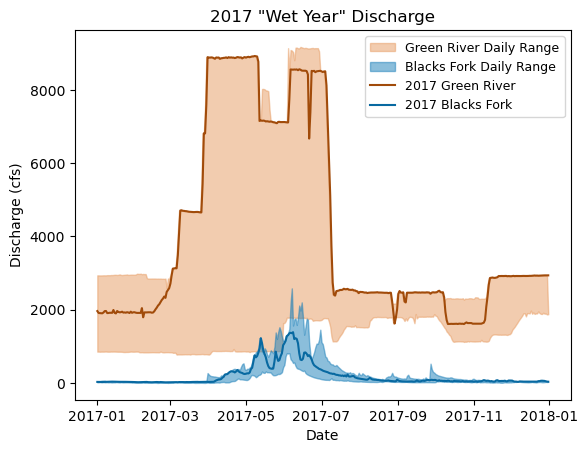

In [6]:
# plot the 2017 data for blacks fork and green river
blackfork_2017 = blackfork[blackfork['Datetime'].dt.year == 2017]
greenriver_2017 = greenriver[greenriver['Datetime'].dt.year == 2017]

#get the min and max flow for each day of the year from the full datasets
greenriver_min = greenriver.groupby(greenriver['Datetime'].dt.dayofyear)['USGS_flow'].min()
greenriver_max = greenriver.groupby(greenriver['Datetime'].dt.dayofyear)['USGS_flow'].max()
blackfork_min = blackfork.groupby(blackfork['Datetime'].dt.dayofyear)['USGS_flow'].min()
blackfork_max = blackfork.groupby(blackfork['Datetime'].dt.dayofyear)['USGS_flow'].max()

#LEAP YEAR!!! Take out February 29th from the min max data so it matches 2017 and 2018 data, which were not leap years
greenriver_min = greenriver_min.drop(60)
greenriver_max = greenriver_max.drop(60)
blackfork_min = blackfork_min.drop(60)
blackfork_max = blackfork_max.drop(60)

#plot 2017 daily data over a shaded area of the min and max found above
plt.fill_between(greenriver_2017['Datetime'], greenriver_min, greenriver_max, color="#E79B6189", alpha=0.5, label='Green River Daily Range')
plt.fill_between(blackfork_2017['Datetime'], blackfork_min, blackfork_max, color="#197EB88D", alpha=0.5, label='Blacks Fork Daily Range')
plt.plot(greenriver_2017['Datetime'], greenriver_2017['USGS_flow'], label='2017 Green River', color="#A14B0A")
plt.plot(blackfork_2017['Datetime'], blackfork_2017['USGS_flow'], label='2017 Blacks Fork', color="#0869A1")
plt.xlabel('Date')
plt.ylabel('Discharge (cfs)')
plt.title('2017 "Wet Year" Discharge')
plt.legend(fontsize=9)

#save plot to media folder
plt.savefig('media/comparative_wet_plot.png', dpi=500)

#show plot
plt.show()

**Aggregation (dry year):** within your plotting function to show the range of flow for each dataset (e.g., min/max for each day), and plot the dry year of interest.

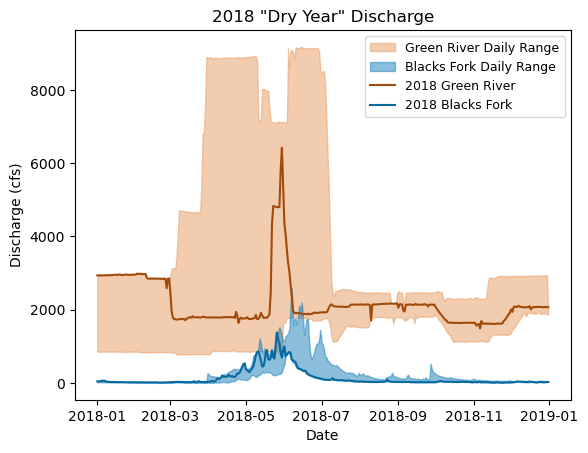

In [5]:
# plot the 2018 data for blacks fork and green river
blackfork_2018 = blackfork[blackfork['Datetime'].dt.year == 2018]
greenriver_2018 = greenriver[greenriver['Datetime'].dt.year == 2018]

#get the min and max flow for each day of the year from the full datasets
greenriver_min = greenriver.groupby(greenriver['Datetime'].dt.dayofyear)['USGS_flow'].min()
greenriver_max = greenriver.groupby(greenriver['Datetime'].dt.dayofyear)['USGS_flow'].max()
blackfork_min = blackfork.groupby(blackfork['Datetime'].dt.dayofyear)['USGS_flow'].min()
blackfork_max = blackfork.groupby(blackfork['Datetime'].dt.dayofyear)['USGS_flow'].max()

#LEAP YEAR!!! Take out February 29th from the min max data so it matches 2017 and 2018 data, which were not leap years
greenriver_min = greenriver_min.drop(60)
greenriver_max = greenriver_max.drop(60)
blackfork_min = blackfork_min.drop(60)
blackfork_max = blackfork_max.drop(60)

#plot 2018 daily data over a shaded area of the min and max found above
plt.fill_between(greenriver_2018['Datetime'], greenriver_min, greenriver_max, color="#E79B6189", alpha=0.5, label='Green River Daily Range')
plt.fill_between(blackfork_2018['Datetime'], blackfork_min, blackfork_max, color="#197EB88D", alpha=0.5, label='Blacks Fork Daily Range')
plt.plot(greenriver_2018['Datetime'], greenriver_2018['USGS_flow'], label='2018 Green River', color="#A14B0A")
plt.plot(blackfork_2018['Datetime'], blackfork_2018['USGS_flow'], label='2018 Blacks Fork', color="#0869A1")
plt.xlabel('Date')
plt.ylabel('Discharge (cfs)')
plt.title('2018 "Dry Year" Discharge')
plt.legend(fontsize=9)

#save plot to media folder
plt.savefig('media/comparative_dry_plot.png', dpi=500)

#show plot
plt.show()

**Engineering Interpretation:** Discuss how the timing of peak flow (e.g., snowmelt pulse) differs between your two compared sets.

In the headwater location, Blacks Fork, peak flow happens later in a wet year than in a dry year. 2017 saw two peaks, but the second one seems to be the larger peak. The two peaks in the wet year could be lower elevation snow melting first (or late spring rain storms or sudden high May temperatures) then higher elevation snowmelt during the peak flow around June. The wet year's second, main peak flow was not the highest that catchment had over the 6-year period (2014-2019), and the residual flow through the rest of the summer was right around the median of all 6 years. The dry year in 2018 had one main peak from one snowmelt pulse in late May/early June. The rest of that year had minimum flows compared to the rest of the 6-year data.

Lower downstream from Blacks Fork, and below Flaming Gorge dam, the Green River is clearly managed. During the wet year, presumably high runoff was controlled in April to a constant ~9,000 cfs (the highest of the 6 years), instead of peaking sharply. Interestingly, the flow was then controlled in May, when the headwater was experiencing its peak flows, perhaps to reduce the amount of runoff in the Green River that comes from other sources downstream of this location in order to control the flood risk in downstream communities. Then, as headwater peak flow is starting to taper off, flow increases again below the dam; this is maybe to keep the Flaming Gorge reservoir at a manageable level, or to supply more water downstream for some specific purpose. The dry year is remarkably different. The year starts with relatively high flows (from the previous wet year in 2017), then flows are kept moderately low (though not the lowest) until runoff season. There is one sharp peak around June, probably to mimic natural runoff processes for downstream ecological health. After this brief peak, discharge is again managed at a mostly steady ~2,000 cfs. 